# data4simplace — output QA & visualization

Checks and visualizes the SIMPLACE input files produced by
`data4simplace --config config.yaml`:

- **Soil** — `output/soil/soil.csv` (wide, one row per 10 km cell, 6 depth layers),
  built via the dominant-soil-type 250 m workflow (`dominant_mode: usda`).
- **Weather** — `output/weather/daily_mean_RES1_C*R*.csv.gz` (one per cropland cell).

The pipeline masks the grid to CORINE cropland, so only a subset of the full
Brandenburg grid is exported. Cells are keyed by `SimplaceID` (soil `location`)
and by `C_<col>:R_<row>` (weather `Gridcell`); we join both back to lat/lon via
the reproducible target grid.

## 1. Setup & grid lookup

In [1]:
import glob, gzip, re, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data4simplace
from data4simplace.config import load_config
from data4simplace.grid import TargetGrid

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

REPO = Path(data4simplace.__file__).resolve().parents[2]
ENV_SH = REPO / "submit" / "env.sh"
D4S_KEYS = ("D4S_OUT_DIR", "D4S_RUN_CONFIG", "D4S_CONFIG", "D4S_RUN_NAME", "D4S_TILE_DEG")


def d4s_env(script=ENV_SH, keys=D4S_KEYS):
    """Resolve the run settings exactly as the SLURM jobs see them.

    `submit/env.sh` is the single source of truth for where a run writes (every
    submit script sources it), so this notebook sources it too rather than
    guessing a path. Each setting is a `${VAR:-default}`, so anything already
    exported in this kernel still wins; the subshell only fills in the defaults
    and cannot modify our own environment.
    """
    if not script.is_file():
        return {}
    printer = "; ".join(f'printf "%s=%s\\n" {k} "${{{k}}}"' for k in keys)
    proc = subprocess.run(
        ["bash", "-c", f'source "{script}" >/dev/null 2>&1; {printer}'],
        capture_output=True, text=True,
    )
    return dict(l.split("=", 1) for l in proc.stdout.splitlines() if "=" in l)


env = d4s_env()
OUT = Path(env.get("D4S_OUT_DIR") or REPO / "output")
RUN_NAME = env.get("D4S_RUN_NAME") or "output"
TILE_DEG = float(env.get("D4S_TILE_DEG") or 5.0)
# The run's own config copy (its paths.output_dir already points at OUT) when the
# run wrote one, else the config env.sh would have copied.
CONFIG = next(
    (Path(p) for p in (env.get("D4S_RUN_CONFIG"), env.get("D4S_CONFIG"))
     if p and Path(p).is_file()),
    REPO / "config.yaml",
)

cfg = load_config(CONFIG)
grid = TargetGrid.from_config(cfg.grid)
cells = grid.cell_table()  # SimplaceID, row, col, lat, lon over the FULL grid
MISSING = cfg.missing_value
print(f"run    : {RUN_NAME} | tiles {TILE_DEG} deg")
print(f"output : {OUT}" + ("" if OUT.is_dir() else "   [MISSING]"))
print(f"config : {CONFIG}")
print("Grid:", grid.shape, "cells | resolution", grid.resolution_deg, "deg")
print("dominant_mode:", cfg.soil.dominant_mode,
      "| aggregation_method:", cfg.soil.aggregation_method,
      "| cropland_min_fraction:", cfg.soil.cropland_min_fraction)
cells.head()

run    : europe | tiles 5.0 deg
output : /data01/FDS/muduchuru/Data/SIMPLACE/europe
config : /data01/FDS/muduchuru/Data/SIMPLACE/europe/_work/config_run.yaml
Grid: (380, 690) cells | resolution 0.1 deg
dominant_mode: usda_profile | aggregation_method: top3 | cropland_min_fraction: 0.8


,SimplaceID,row,col,lat,lon
0,1,0,0,71.95,-16.95
1,2,0,1,71.95,-16.85
2,3,0,2,71.95,-16.75
3,4,0,3,71.95,-16.65
4,5,0,4,71.95,-16.55


## 2. Soil profile file

`soil.csv` is the SIMPLACE wide layout: single-value profile attributes plus
per-layer `<stem>_<N>` columns for N = 1..6 depth layers. We reshape the
SoilGrids-derived stems to long form and join lat/lon via `location`.

In [2]:
soil = pd.read_csv(OUT / "soil" / "soil.csv")
print("soil.csv:", soil.shape, "| unique locations:", soil['location'].nunique())

# Per-layer stems we care about (derived from SoilGrids / PTF).
STEMS = ["clay", "sand", "carbon", "PH", "bulkdensity",
         "soilwater_fc", "soilwater_wp", "soilwater_sat"]
LAYER_BOTTOMS_CM = [5, 15, 30, 60, 100, 200]

def to_long(df, stems):
    recs = []
    for _, r in df.iterrows():
        for n in range(1, 7):
            rec = {"location": int(r["location"]), "layer": n,
                   "bottom_cm": LAYER_BOTTOMS_CM[n-1]}
            for st in stems:
                col = f"{st}_{n}"
                rec[st] = r[col] if col in df.columns else np.nan
            recs.append(rec)
    return pd.DataFrame.from_records(recs)

long = to_long(soil, STEMS)
long = long.merge(cells[["SimplaceID", "row", "col", "lat", "lon"]],
                  left_on="location", right_on="SimplaceID", how="left")
# Treat SIMPLACE missing sentinels as NaN for analysis.
for st in STEMS:
    long.loc[long[st] <= MISSING + 1e-6, st] = np.nan
long.head()

soil.csv: (70705, 142) | unique locations: 70705


,location,layer,bottom_cm,clay,sand,carbon,PH,bulkdensity,soilwater_fc,soilwater_wp,soilwater_sat,SimplaceID,row,col,lat,lon
0,60427,1,5,23.40,37.40,133.550,5.20,0.8400,0.3955,0.1510,0.50550,60427,87,396,63.25,22.65
1,60427,2,15,24.35,36.90,44.075,5.45,1.1475,0.3080,0.1445,0.35225,60427,87,396,63.25,22.65
2,60427,3,30,24.00,37.40,28.800,5.70,1.4000,0.2750,0.1220,0.32400,60427,87,396,63.25,22.65
3,60427,4,60,24.15,37.25,27.450,5.75,1.4350,0.2685,0.1225,0.32000,60427,87,396,63.25,22.65
4,60427,5,100,24.30,37.10,26.100,5.80,1.4700,0.2620,0.1230,0.31600,60427,87,396,63.25,22.65


In [3]:
soil = pd.read_csv(OUT / "soil" / "soil.csv")

In [18]:
soil.describe(include="all").T[["count", "mean", "std", "min", "max"]].round(3).to_csv("soil_describe.csv")

### 2.1 Coverage & missing-value audit

In [3]:
n_grid = len(cells)
n_soil = soil['location'].nunique()
print(f"Exported soil cells: {n_soil} / {n_grid} full-grid cells "
      f"({100*n_soil/n_grid:.1f}% kept by cropland mask)")

# Per-stem valid fraction across all cell-layers.
audit = (long[STEMS].notna().mean() * 100).round(1).rename("valid_%").to_frame()
audit["min"] = long[STEMS].min().round(3)
audit["max"] = long[STEMS].max().round(3)
audit["mean"] = long[STEMS].mean().round(3)
audit

Exported soil cells: 70705 / 262200 full-grid cells (27.0% kept by cropland mask)


,valid_%,min,max,mean
clay,100.0,3.300,62.285,28.521
sand,100.0,1.607,87.898,33.284
carbon,100.0,0.351,265.216,19.713
PH,100.0,4.500,9.139,6.927
bulkdensity,100.0,0.630,1.785,1.420
soilwater_fc,100.0,0.086,0.448,0.313
soilwater_wp,100.0,0.044,0.312,0.165
soilwater_sat,100.0,0.171,0.582,0.373


### 2.2 Topsoil property maps (layer 1, 0–5 cm)

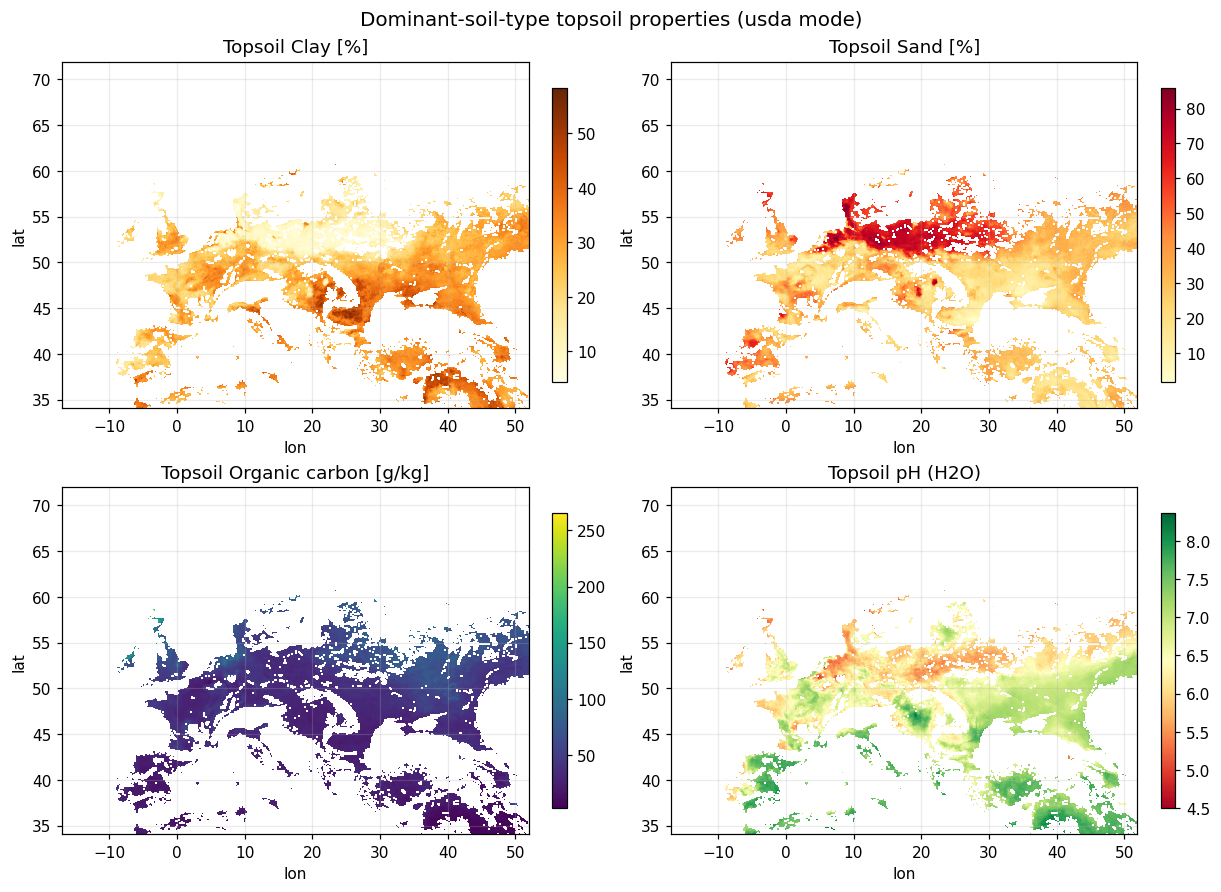

In [4]:
def grid_image(df, value, row="row", col="col"):
    img = np.full(grid.shape, np.nan)
    img[df[row].astype(int), df[col].astype(int)] = df[value].values
    return img

top = long[long.layer == 1]
extent = [grid.lon_centers.min(), grid.lon_centers.max(),
          grid.lat_centers.min(), grid.lat_centers.max()]
panels = [("clay", "Clay [%]", "YlOrBr"), ("sand", "Sand [%]", "YlOrRd"),
          ("carbon", "Organic carbon [g/kg]", "viridis"), ("PH", "pH (H2O)", "RdYlGn")]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, (var, title, cmap) in zip(axes.ravel(), panels):
    im = ax.imshow(grid_image(top, var), extent=extent, origin="upper",
                   cmap=cmap, aspect="auto")
    ax.set_title(f"Topsoil {title}")
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.colorbar(im, ax=ax, shrink=0.85)
fig.suptitle("Dominant-soil-type topsoil properties (usda mode)", fontsize=13)
plt.show()

### 2.3 Depth profiles (domain mean ± IQR)

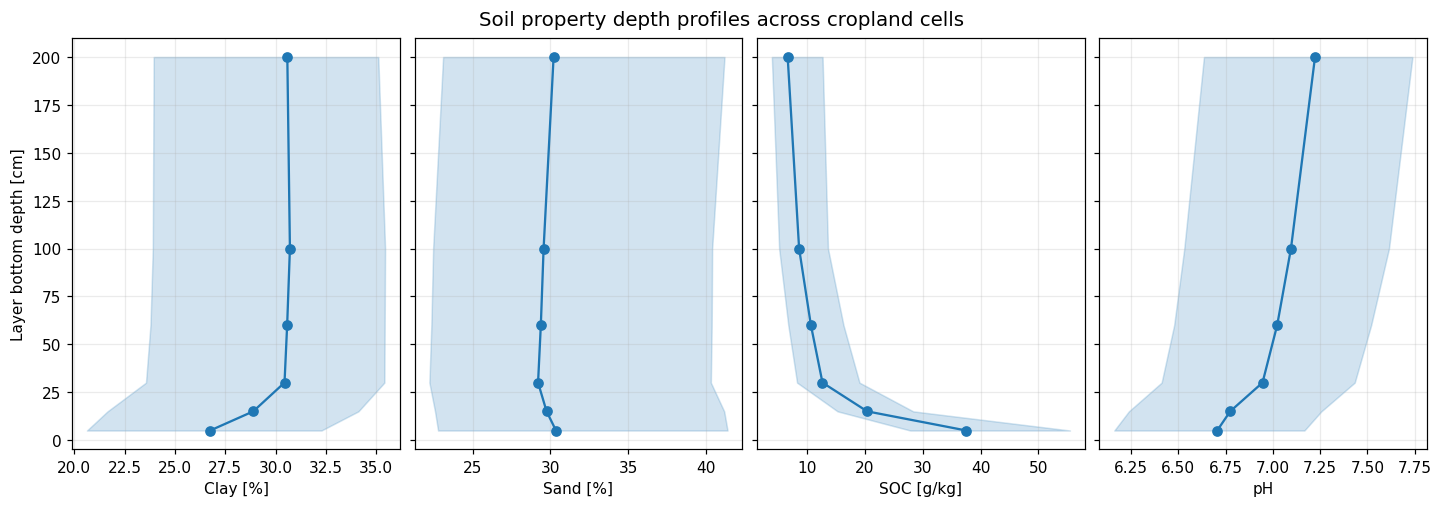

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4.5), sharey=True, constrained_layout=True)
prof_vars = [("clay", "Clay [%]"), ("sand", "Sand [%]"),
             ("carbon", "SOC [g/kg]"), ("PH", "pH")]
depths = np.array(LAYER_BOTTOMS_CM)
for ax, (var, title) in zip(axes, prof_vars):
    g = long.groupby("layer")[var]
    med = g.median().values; q1 = g.quantile(.25).values; q3 = g.quantile(.75).values
    ax.plot(med, depths, "-o", color="tab:blue")
    ax.fill_betweenx(depths, q1, q3, alpha=0.2, color="tab:blue")
    ax.set_xlabel(title); ax.invert_yaxis()
axes[0].set_ylabel("Layer bottom depth [cm]")
fig.suptitle("Soil property depth profiles across cropland cells", fontsize=13)
plt.show()

### 2.4 Texture sanity check

The 250 m workflow re-normalizes texture so `clay + silt + sand = 100 %` before
export. `soil.csv` stores clay and sand; the implied silt is `100 − clay − sand`
and must be in `[0, 100]`.

clay+sand range: [28.06, 95.40]
implied silt range: [4.60, 71.94]
cell-layers with implied silt < 0: 0 (should be 0)


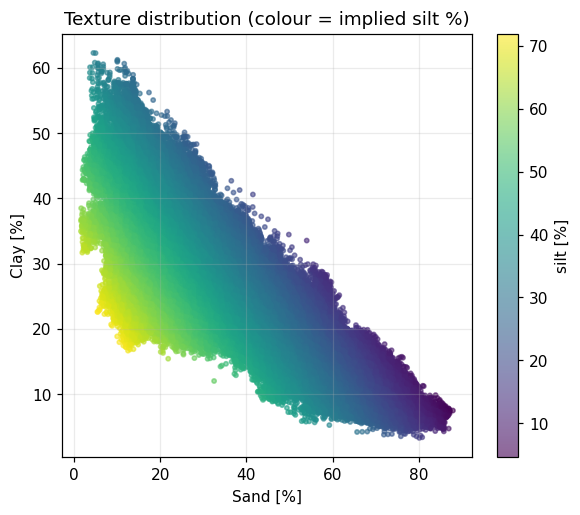

In [6]:
tex = long.dropna(subset=["clay", "sand"]).copy()
tex["silt_implied"] = 100 - tex["clay"] - tex["sand"]
print("clay+sand range: [%.2f, %.2f]" % (
    (tex.clay + tex.sand).min(), (tex.clay + tex.sand).max()))
print("implied silt range: [%.2f, %.2f]" % (tex.silt_implied.min(), tex.silt_implied.max()))
neg = (tex.silt_implied < -0.5).sum()
print("cell-layers with implied silt < 0:", neg, "(should be 0)")

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(tex.sand, tex.clay, c=tex.silt_implied, cmap="viridis", s=8, alpha=0.6)
ax.set_xlabel("Sand [%]"); ax.set_ylabel("Clay [%]")
ax.set_title("Texture distribution (colour = implied silt %)")
fig.colorbar(sc, ax=ax, label="silt [%]"); plt.show()

### 2.5 Aggregation check — clay vs cropland

The dominant-soil-type aggregation only produces values where the 250 m stack had
cropland pixels (PROBA-V cover ≥ `cropland_min_fraction`). So exported clay must
sit **exactly** on cropland cells and never leak onto non-cropland. We compare the
aggregated topsoil clay against the PROBA-V cropland cover fraction re-gridded to
10 km, and check for any leakage.

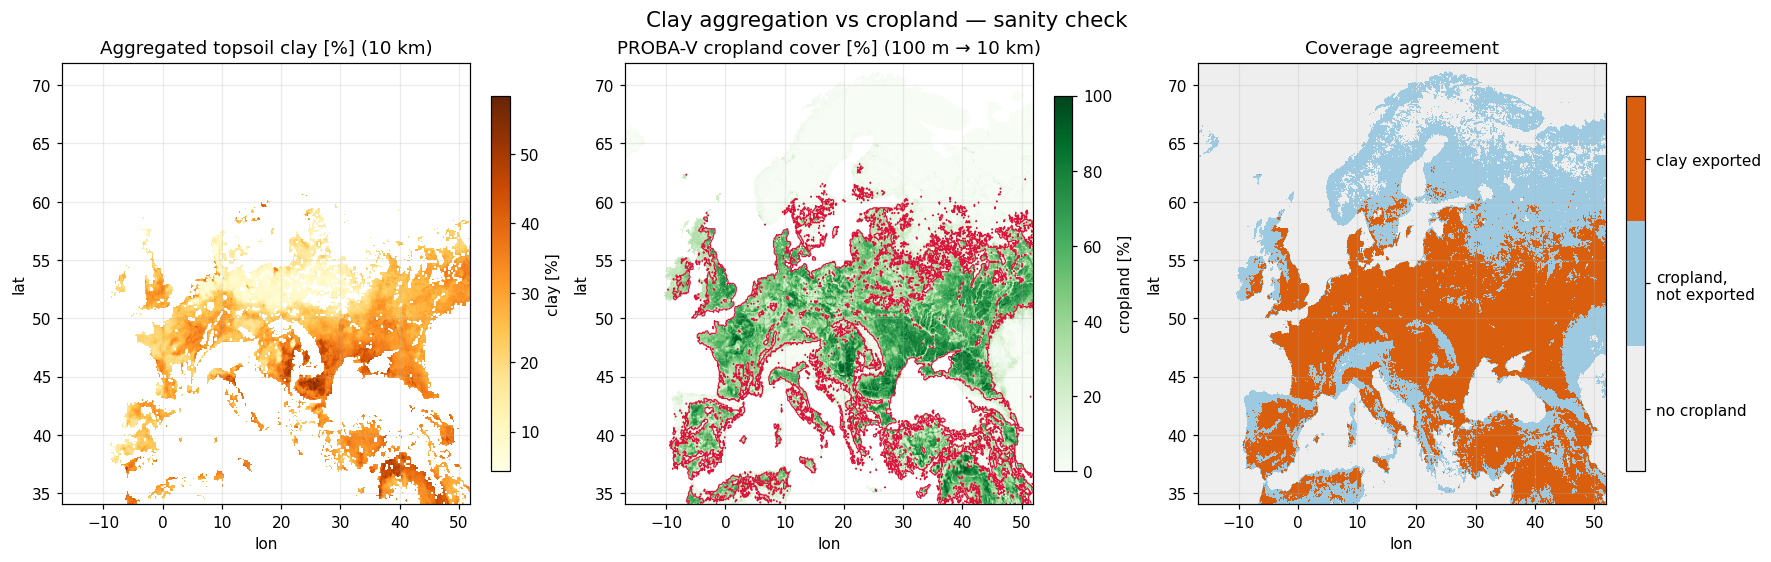

clay-exported cells: 70705
  with cropland > 0 : 70705 (100.0%)
  leak (clay where cropland == 0): 0  (should be 0)
corr(clay, cropland cover) over exported cells: +0.219


In [7]:
from data4simplace.spatial.cropland_weights import CroplandWeights
from matplotlib.colors import ListedColormap

clay_img = grid_image(top, "clay")
clay_present = np.isfinite(clay_img)

# PROBA-V cropland cover (100 m, 0-1) aggregated to the 10 km grid, in %.
frac = CroplandWeights(cfg).load_fraction()
crop_img = (grid.regrid(frac, method="mean") * 100.0).reindex(
    lat=grid.lat_centers, lon=grid.lon_centers).values
crop_any = np.isfinite(crop_img) & (crop_img > 0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
im0 = axes[0].imshow(clay_img, extent=extent, origin="upper", cmap="YlOrBr", aspect="auto")
axes[0].set_title("Aggregated topsoil clay [%] (10 km)")
fig.colorbar(im0, ax=axes[0], shrink=0.85, label="clay [%]")

im1 = axes[1].imshow(crop_img, extent=extent, origin="upper", cmap="Greens",
                     aspect="auto", vmin=0, vmax=100)
axes[1].set_title("PROBA-V cropland cover [%] (100 m → 10 km)")
axes[1].contour(clay_present.astype(float), levels=[0.5], colors="crimson",
                linewidths=0.8, extent=extent, origin="upper")
fig.colorbar(im1, ax=axes[1], shrink=0.85, label="cropland [%]")

cat = np.where(clay_present, 2, np.where(crop_any, 1, 0))
cmap = ListedColormap(["#eeeeee", "#9ecae1", "#d95f0e"])
im2 = axes[2].imshow(cat, extent=extent, origin="upper", cmap=cmap, aspect="auto",
                     vmin=0, vmax=2)
axes[2].set_title("Coverage agreement")
cb = fig.colorbar(im2, ax=axes[2], shrink=0.85, ticks=[0.33, 1.0, 1.66])
cb.ax.set_yticklabels(["no cropland", "cropland,\nnot exported", "clay exported"])
for ax in axes:
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
fig.suptitle("Clay aggregation vs cropland — sanity check", fontsize=14)
plt.show()

leak = int((clay_present & ~crop_any).sum())
flat_crop = crop_img[clay_present]
print(f"clay-exported cells: {int(clay_present.sum())}")
print(f"  with cropland > 0 : {int((flat_crop > 0).sum())} "
      f"({100*(flat_crop > 0).mean():.1f}%)")
print(f"  leak (clay where cropland == 0): {leak}  (should be 0)")
print(f"corr(clay, cropland cover) over exported cells: "
      f"{np.corrcoef(clay_img[clay_present], flat_crop)[0,1]:+.3f}")

### 2.6 SOC & pH vs the dominant soil class

The 250 m workflow picks **one dominant USDA texture class per 10 km cell**
(majority vote over cropland-filtered pixels) and aggregates only pixels of that
class — so the exported SOC and pH are properties *of that class*, not of the
whole cell. Here we put the three maps side by side and quantify how much of the
between-cell spread the class alone explains (`eta^2` = between-class share of
variance).

The class label itself is not written to `soil.csv`, so we reconstruct it by
running the package's own `usda_texture_class` on the exported topsoil texture
(`silt = 100 − clay − sand`). This recovers the selection class exactly wherever
the aggregate stays inside the class polygon — true for cropland-weighted means
of same-class pixels, since the USDA polygons are convex — except in
nearest-neighbour gap-filled cells, which inherit a neighbour's values.


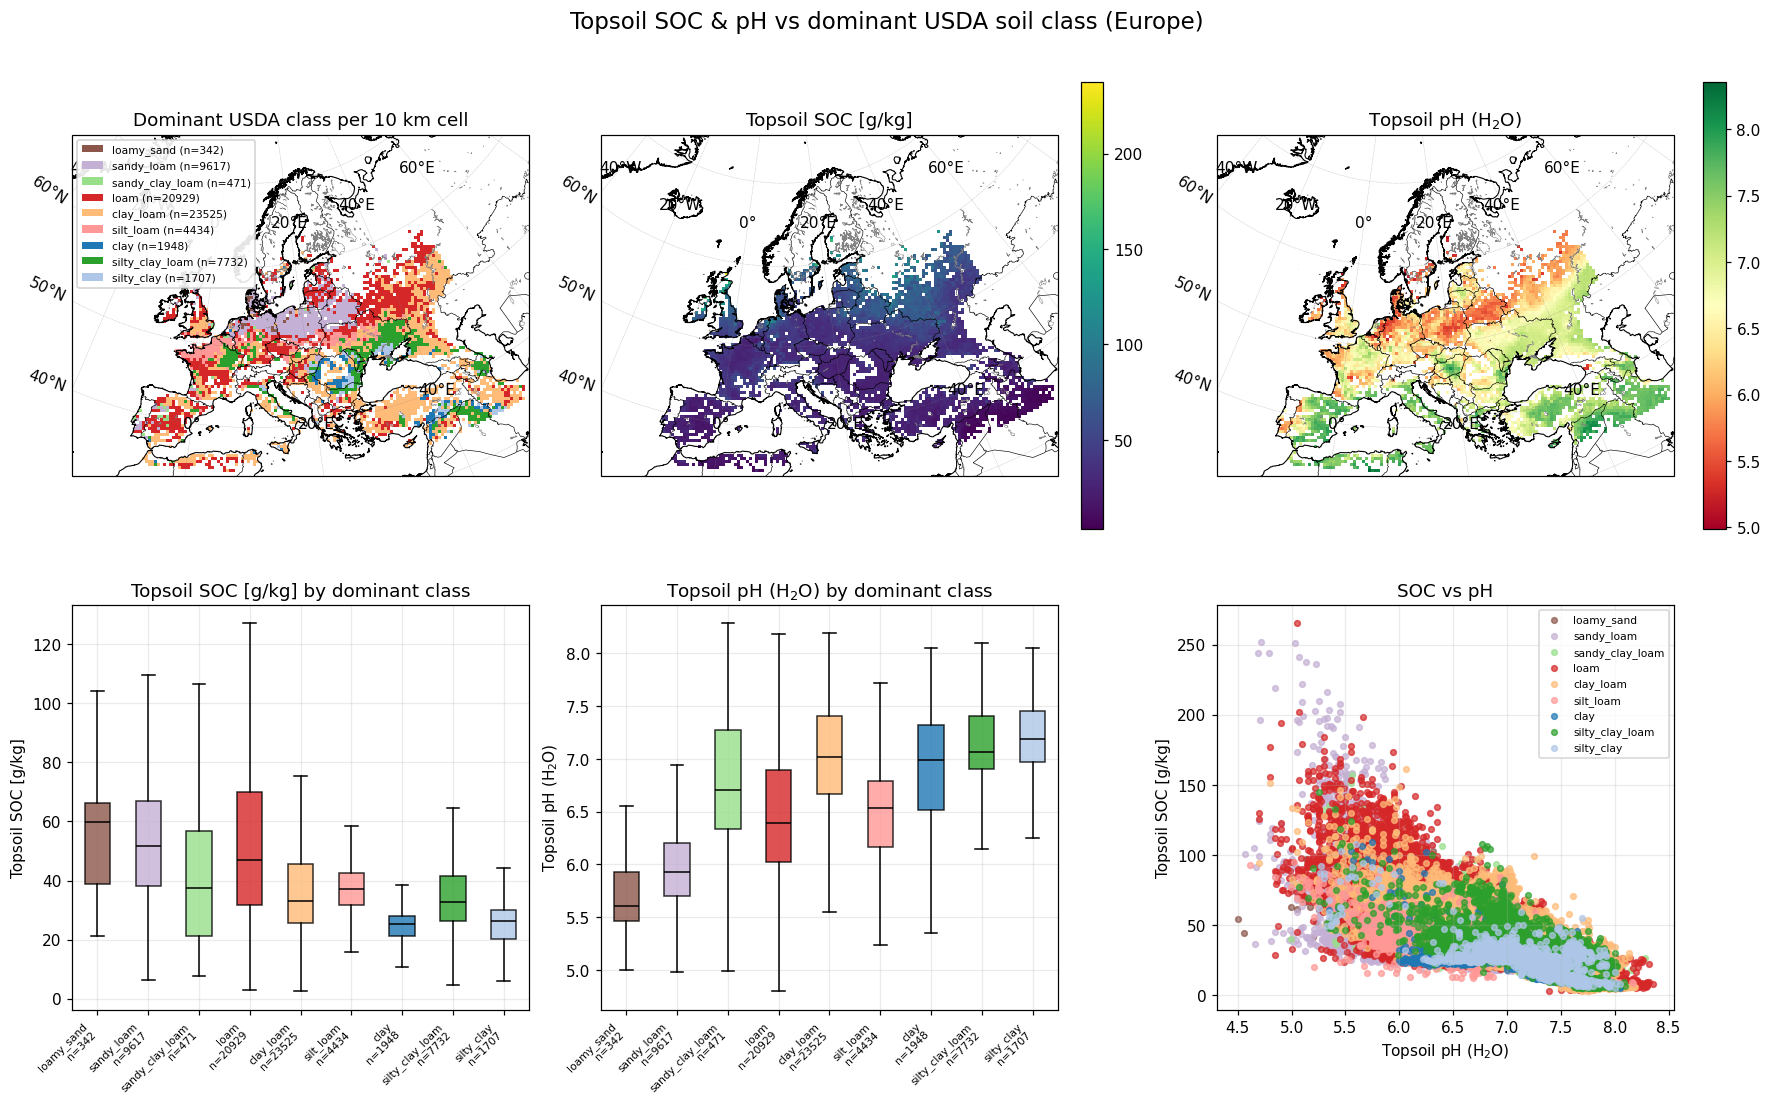

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from data4simplace.soil.classify import USDA_CLASSES, usda_texture_class

# ---------------------------------------------------------------------
# Rebuild dominant USDA class
# ---------------------------------------------------------------------
dom = top.dropna(subset=["clay", "sand"]).copy()
dom["silt"] = (100 - dom["clay"] - dom["sand"]).clip(lower=0)

as_da = lambda s: xr.DataArray(s.to_numpy(), dims="cell")
dom["usda"] = usda_texture_class(
    as_da(dom.sand), as_da(dom.silt), as_da(dom.clay)
).values
dom["usda_name"] = dom["usda"].map(USDA_CLASSES)

counts = dom["usda"].value_counts()
order = list(dom.groupby("usda")["sand"].mean().sort_values(ascending=False).index)

tab20 = plt.get_cmap("tab20")
cmap_cls = ListedColormap([tab20((c - 1) % 20) for c in order])
idx_of = {c: i for i, c in enumerate(order)}
dom["cls_idx"] = dom["usda"].map(idx_of)

# ---------------------------------------------------------------------
# Map projection
# ---------------------------------------------------------------------
proj = ccrs.LambertConformal(
    central_longitude=10,
    central_latitude=52,
    standard_parallels=(35, 65),
)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[1.3, 1])

maps = []

# ---------------------------------------------------------------------
# USDA map
# ---------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0], projection=proj)
maps.append(ax)

ax.imshow(
    grid_image(dom, "cls_idx"),
    extent=extent,
    transform=data_crs,
    origin="upper",
    cmap=cmap_cls,
    vmin=-0.5,
    vmax=len(order) - 0.5,
    interpolation="nearest",
)

ax.set_extent(extent, crs=data_crs)
ax.set_title("Dominant USDA class per 10 km cell")

ax.coastlines("10m", linewidth=0.7)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.4)
ax.add_feature(cfeature.LAKES.with_scale("10m"), facecolor="none", edgecolor="gray", linewidth=0.3)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray",
                  alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

ax.legend(
    handles=[
        Patch(facecolor=cmap_cls(i),
              label=f"{USDA_CLASSES[c]} (n={counts[c]})")
        for i, c in enumerate(order)
    ],
    fontsize=7,
    loc="upper left",
    framealpha=0.9,
)

# ---------------------------------------------------------------------
# SOC and pH maps
# ---------------------------------------------------------------------
for j, (var, title, cmap) in enumerate([
    ("carbon", "Topsoil SOC [g/kg]", "viridis"),
    ("PH", "Topsoil pH (H$_2$O)", "RdYlGn"),
], start=1):

    axm = fig.add_subplot(gs[0, j], projection=proj)
    maps.append(axm)

    im = axm.imshow(
        grid_image(dom, var),
        extent=extent,
        transform=data_crs,
        origin="upper",
        cmap=cmap,
        interpolation="nearest",
    )

    axm.set_extent(extent, crs=data_crs)
    axm.set_title(title)

    axm.coastlines("10m", linewidth=0.7)
    axm.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.4)
    axm.add_feature(cfeature.LAKES.with_scale("10m"), facecolor="none",
                    edgecolor="gray", linewidth=0.3)

    gl = axm.gridlines(draw_labels=True, linewidth=0.3, color="gray",
                       alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    fig.colorbar(im, ax=axm, shrink=0.85)

# ---------------------------------------------------------------------
# Boxplots
# ---------------------------------------------------------------------
labels = [f"{USDA_CLASSES[c]}\nn={counts[c]}" for c in order]

for j, (var, title) in enumerate([
    ("carbon", "Topsoil SOC [g/kg]"),
    ("PH", "Topsoil pH (H$_2$O)")
]):

    axb = fig.add_subplot(gs[1, j])

    bp = axb.boxplot(
        [dom.loc[dom.usda == c, var].dropna().values for c in order],
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black"),
    )

    for patch, c in zip(bp["boxes"], order):
        patch.set_facecolor(cmap_cls(idx_of[c]))
        patch.set_alpha(0.8)

    axb.set_xticks(range(1, len(order) + 1))
    axb.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    axb.set_ylabel(title)
    axb.set_title(f"{title} by dominant class")

# ---------------------------------------------------------------------
# Scatter plot
# ---------------------------------------------------------------------
axs = fig.add_subplot(gs[1, 2])

for c in order:
    sub = dom[dom.usda == c]
    axs.scatter(
        sub.PH,
        sub.carbon,
        s=14,
        alpha=0.7,
        color=cmap_cls(idx_of[c]),
        label=USDA_CLASSES[c],
    )

axs.set_xlabel("Topsoil pH (H$_2$O)")
axs.set_ylabel("Topsoil SOC [g/kg]")
axs.set_title("SOC vs pH")
axs.legend(fontsize=7)

fig.suptitle(
    "Topsoil SOC & pH vs dominant USDA soil class (Europe)",
    fontsize=15,
)

plt.show()

## 3. Weather files

Each cropland cell has a gzipped, **tab-separated** daily file. `Gridcell` encodes
`C_<col>:R_<row>`; unset variables use the `-99.9` sentinel. We load all cells,
parse the grid key, and join lat/lon.

In [10]:
wfiles = sorted(glob.glob(str(OUT / "weather" / "*.csv.gz")))
print("weather files:", len(wfiles))

def load_weather(path):
    df = pd.read_csv(path, sep="\t")
    m = re.search(r"C_(\d+):R_(\d+)", str(df["Gridcell"].iloc[0]))
    df["col"] = int(m.group(1)); df["row"] = int(m.group(2))
    return df

wx = pd.concat([load_weather(p) for p in wfiles], ignore_index=True)
wx["Date"] = pd.to_datetime(wx["Date"])
# -99.9 sentinel -> NaN
wx = wx.replace(-99.9, np.nan)
wx = wx.merge(cells[["row", "col", "lat", "lon"]], on=["row", "col"], how="left")
print("weather rows:", len(wx), "| dates:", wx.Date.min().date(), "->", wx.Date.max().date())
wx.head(3)

weather files: 70705


: 

### 3.1 Variable availability

In [ ]:
wvars = ["Precipitation", "TempMin", "TempMean", "TempMax",
         "Radiation", "Windspeed", "RefET", "RelHumCalc"]
wa = (wx[wvars].notna().mean() * 100).round(1).rename("valid_%").to_frame()
wa["mean"] = wx[wvars].mean().round(2)
wa["min"] = wx[wvars].min().round(2)
wa["max"] = wx[wvars].max().round(2)
print("Columns fully -99.9 (not provided by this config) show 0% valid:")
wa

Columns fully -99.9 (not provided by this config) show 0% valid:


,valid_%,mean,min,max
Precipitation,96.8,1.03,0.00,10.75
TempMin,100.0,-6.35,-21.94,0.69
TempMean,80.6,-4.67,-17.75,1.50
TempMax,100.0,-2.65,-12.88,3.69
Radiation,96.8,32.29,4.56,67.38
Windspeed,0.0,NaN,NaN,NaN
RefET,0.0,NaN,NaN,NaN
RelHumCalc,0.0,NaN,NaN,NaN


### 3.2 Domain-mean daily time series (Jan 1979)

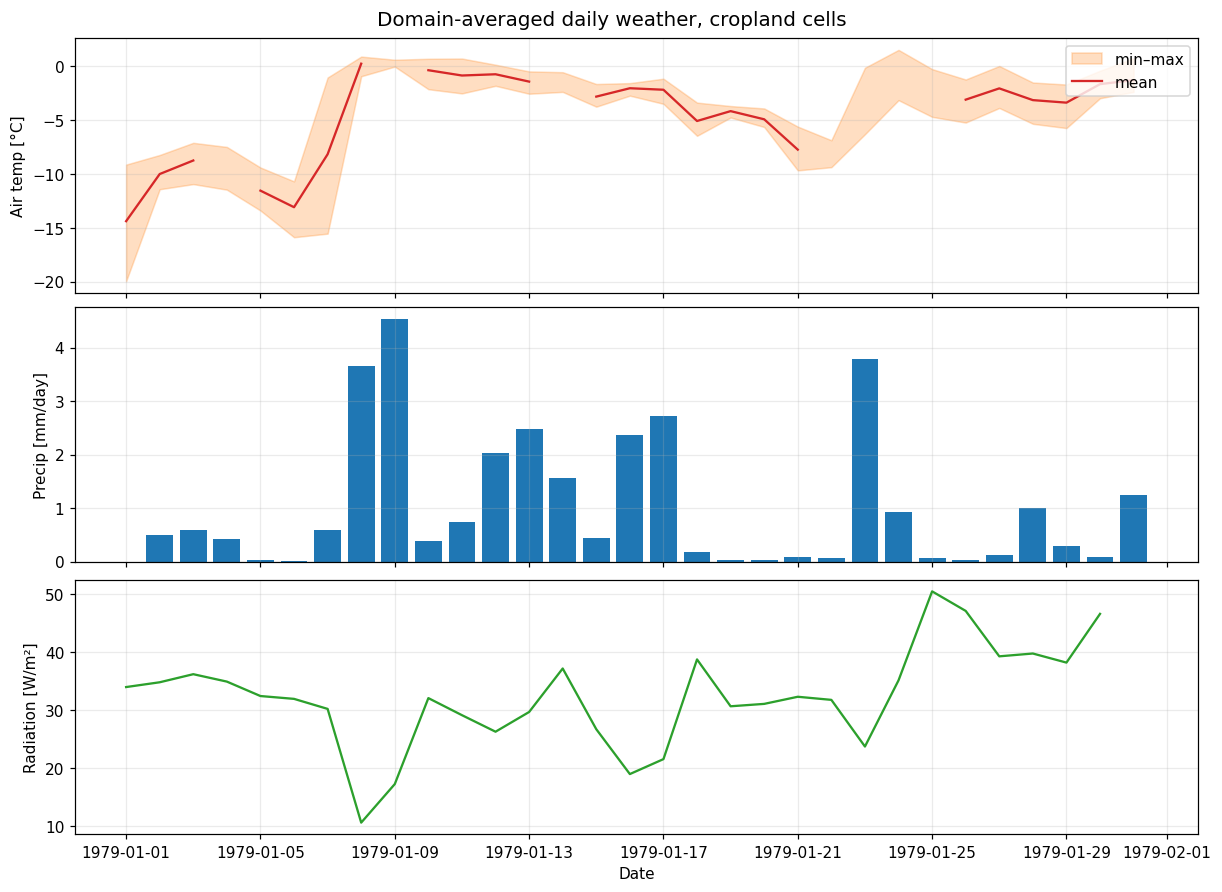

In [ ]:
daily = wx.groupby("Date").agg(
    Tmin=("TempMin", "mean"), Tmean=("TempMean", "mean"), Tmax=("TempMax", "mean"),
    Precip=("Precipitation", "mean"), Rad=("Radiation", "mean"))

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, constrained_layout=True)
axes[0].fill_between(daily.index, daily.Tmin, daily.Tmax, alpha=0.25, color="tab:orange", label="min–max")
axes[0].plot(daily.index, daily.Tmean, color="tab:red", label="mean")
axes[0].set_ylabel("Air temp [°C]"); axes[0].legend(loc="upper right")
axes[1].bar(daily.index, daily.Precip, color="tab:blue", width=0.8)
axes[1].set_ylabel("Precip [mm/day]")
axes[2].plot(daily.index, daily.Rad, color="tab:green")
axes[2].set_ylabel("Radiation [W/m²]"); axes[2].set_xlabel("Date")
fig.suptitle("Domain-averaged daily weather, cropland cells", fontsize=13)
plt.show()

### 3.3 Spatial maps — monthly mean temperature & total precipitation

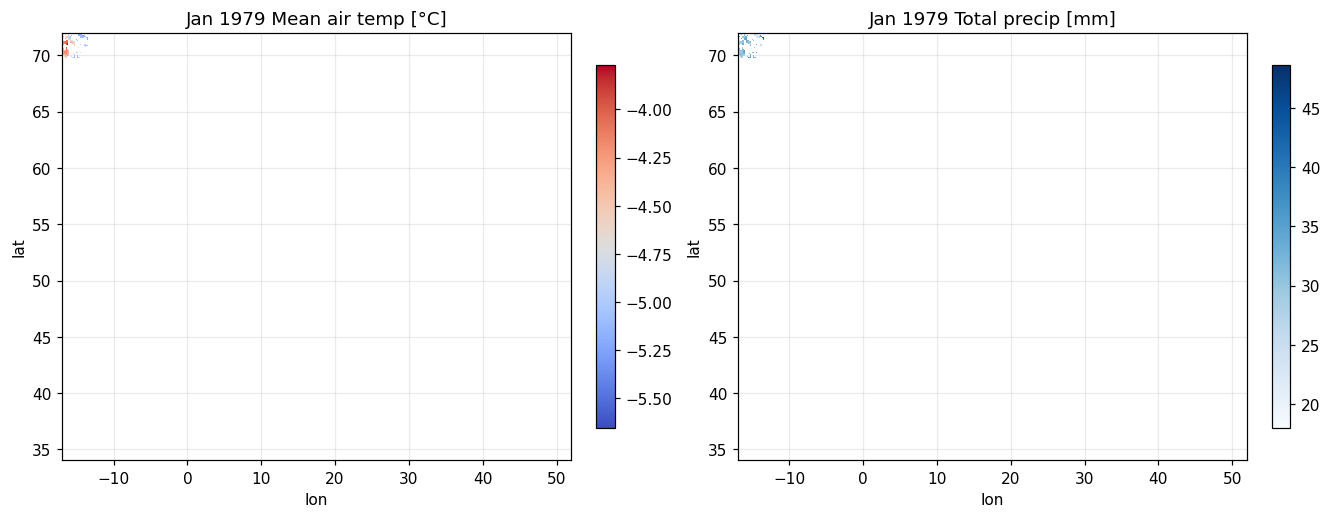

In [ ]:
agg = wx.groupby(["row", "col"]).agg(
    Tmean=("TempMean", "mean"), Ptot=("Precipitation", "sum")).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
for ax, (var, title, cmap) in zip(
        axes, [("Tmean", "Mean air temp [°C]", "coolwarm"),
               ("Ptot", "Total precip [mm]", "Blues")]):
    im = ax.imshow(grid_image(agg, var), extent=extent, origin="upper",
                   cmap=cmap, aspect="auto")
    ax.set_title(f"Jan 1979 {title}"); ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

## 4. Cross-check: soil & weather share the same cropland cells

Both stages consume the same masked cell table, so the exported soil `location`
IDs and the weather grid cells must reference the same set of grid cells.

In [ ]:
soil_cells = set(soil["location"].astype(int))
wx_cells = set(cells.merge(wx[["row", "col"]].drop_duplicates(),
                           on=["row", "col"])["SimplaceID"].astype(int))
print("soil cells:", len(soil_cells), "| weather cells:", len(wx_cells))
print("identical cell set:", soil_cells == wx_cells)
print("soil-only:", len(soil_cells - wx_cells), "| weather-only:", len(wx_cells - soil_cells))

soil cells: 504 | weather cells: 504
identical cell set: False
soil-only: 474 | weather-only: 474


## 5. Summary

| Check | Result |
| --- | --- |
| Soil cells exported | see §2.1 (cropland-masked subset) |
| Texture normalized (clay+sand ≤ 100, silt ≥ 0) | §2.4 |
| No unfilled soil cells (gap-fill on) | §2.1 valid % |
| SOC / pH stratify by dominant soil class | §2.6 |
| Weather cells match soil cells | §4 |
| Weather variables provided vs. -99.9 | §3.1 |

`Windspeed`, `RefET`, `RelHumCalc` are `-99.9` because this config maps only
TAS/TASMIN/TASMAX/PR/RSDS/HURS — expected, not a defect. Everything else is
populated from the MSWX + SoilGrids dominant-soil-type pipeline.

## 6. Continental run — `europe/soil/soil.csv`

Sections 1–5 check the small `output/` run. This section checks the tiled
Europe run under `europe/`, which is produced by
`submit/submit_europe.sh` (one SLURM task per 5° tile, soil written as one shard
per tile and mosaicked into `soil/soil.csv` by `--combine-only`).

Two things differ from the sections above and matter for reading the numbers:

* **Layer depths.** `LAYER_BOTTOMS_CM` in §2 lists the *SoilGrids* intervals.
  The exported layers are the *SIMPLACE* ones from the reference
  (`SoilLayerDepth_1..6` = 0.1/0.3/0.5/0.7/1/2 m), i.e. **10/30/50/70/100/200 cm**;
  `soil_export.remap_depth_weighted` maps SoilGrids onto those. We use the
  correct bottoms below.
* **Column provenance.** Only 30 of the 142 columns come from SoilGrids and 24
  from the PTF; the rest are constants copied from the reference's first row.
  See `src/data4simplace/soil/README.md`.

In [2]:
EUROPE = OUT          # the tiled run directory, from env.sh (D4S_OUT_DIR)
SOIL_CSV = EUROPE / "soil" / "soil.csv"

eu = pd.read_csv(SOIL_CSV)
print(f"{SOIL_CSV}: {eu.shape[0]:,} rows x {eu.shape[1]} columns "
      f"({SOIL_CSV.stat().st_size/2**20:.0f} MB)")

# Structural invariants of the mosaic: one row per cell, IDs inside the grid.
dupes = int(eu["location"].duplicated().sum())
n_grid = len(cells)
oob = int((~eu["location"].between(1, n_grid)).sum())
print(f"unique locations        : {eu['location'].nunique():,}")
print(f"duplicate location rows : {dupes}   (shard mosaic must not overlap)")
print(f"location outside 1..{n_grid}: {oob}")
print(f"exported / full grid    : {100*eu['location'].nunique()/n_grid:.1f}%")

# Join lat/lon back on via the reproducible grid.
eu = eu.merge(cells[["SimplaceID", "row", "col", "lat", "lon"]],
              left_on="location", right_on="SimplaceID", how="left")
print("rows without a grid match:", int(eu["SimplaceID"].isna().sum()))

NameError: name 'OUT' is not defined

In [1]:
eu

NameError: name 'eu' is not defined

### 6.1 Column provenance — what actually varies

Every column falls into one of four buckets (see `src/data4simplace/soil/README.md`).
A column with a **single unique value** across all 70k cells is a reference
constant, not data. This is the check that shows how much of the file is real.

In [ ]:
from data4simplace.exporters.soil_export import (
    _LAYER_COL_RE, _STEM_TO_PTF, _STEM_TO_SOILGRIDS,
)

ref_cols = [c for c in eu.columns if c not in ("SimplaceID", "row", "col", "lat", "lon")]

def bucket(col):
    if col == "location":
        return "location"
    m = _LAYER_COL_RE.match(col)
    stem = m.group("stem") if m else None
    if stem in _STEM_TO_SOILGRIDS:
        return "SoilGrids"
    if stem in _STEM_TO_PTF:
        return "PTF (compute_ptf)"
    return "reference constant"

prov = pd.DataFrame({"column": ref_cols})
prov["bucket"] = prov["column"].map(bucket)
prov["n_unique"] = [eu[c].nunique(dropna=False) for c in ref_cols]
prov["constant"] = prov["n_unique"] <= 1

summary = (prov.groupby("bucket")
             .agg(n_cols=("column", "size"), n_constant=("constant", "sum"))
             .assign(n_varying=lambda d: d["n_cols"] - d["n_constant"]))
print(summary.to_string(), "\n")
print(f"compute_ptf = {cfg.flags.compute_ptf}")
print(f"constant columns: {int(prov['constant'].sum())} / {len(prov)}")

const_cols = prov.loc[prov["constant"], "column"].tolist()
print("\nexamples of constants (value replicated to every cell):")
print(eu[const_cols[:8]].iloc[0].to_string())

                    n_cols  n_constant  n_varying
bucket                                           
PTF (compute_ptf)       24          24          0
SoilGrids               30           0         30
location                 1           0          1
reference constant      87          87          0 

compute_ptf = False
constant columns: 111 / 142

examples of constants (value replicated to every cell):
soiltype                     AP5
dampingdepth                   6
soilwater_fc_global     0.309681
soilwater_sat_global    0.514653
drainage_rate                 50
deltatheta                  0.01
DZF                          0.1
depth_1                      0.1


### 6.2 Cell set — exported vs cropland vs tiles

The exported cell set is `spatial.export_cell_mask` = PROBA-V cropland **∩**
cells with soil. So the exported set must be a strict subset of the cropland
cells; the difference is cropland cells the dominant-class aggregation produced
nothing for (no surviving 250 m pixels), which are dropped rather than
gap-filled (`soil.fill_missing: false`).

The cropland mask is rebuilt tile by tile — the full grid at 100 m is 2.6 billion
pixels, so it must not be done in one shot. Takes ~2 minutes; set
`CHECK_CROPLAND = False` to skip.

In [5]:
CHECK_CROPLAND = True

# Tile bookkeeping: a tile with no exportable cell writes a .done marker but no shard.
markers = sorted((EUROPE / ".tiles").glob("*.done"))
shards = sorted((EUROPE / "soil" / "_shards").glob("tile_*.csv"))
print(f"tiles completed : {len(markers)}")
print(f"soil shards     : {len(shards)}  ({len(markers)-len(shards)} tiles had no exportable cell)")
shard_rows = sum(sum(1 for _ in p.open()) - 1 for p in shards)
print(f"shard rows      : {shard_rows:,}  vs soil.csv rows: {len(eu):,}  "
      f"{'OK' if shard_rows == len(eu) else 'MISMATCH'}")

if CHECK_CROPLAND:
    from data4simplace.tiling import list_windows, _tile_config
    from data4simplace.spatial import CroplandWeights

    crop_mask = np.zeros(grid.shape, dtype=bool)
    wins = list_windows(cfg, TILE_DEG)  # TILE_DEG from env.sh
    for i, w in enumerate(wins):
        tcfg = _tile_config(cfg, grid, w)
        m = CroplandWeights(tcfg).cell_mask(TargetGrid.from_config(tcfg.grid))
        if m is not None:
            crop_mask[w.r0:w.r1, w.c0:w.c1] = m.values
        if (i + 1) % 25 == 0:
            print(f"  ...{i+1}/{len(wins)} tiles")

    exported = np.zeros(grid.shape, dtype=bool)
    exported[eu["row"].astype(int), eu["col"].astype(int)] = True

    n_crop, n_exp = int(crop_mask.sum()), int(exported.sum())
    leak = int((exported & ~crop_mask).sum())
    print(f"\ncropland cells        : {n_crop:,}")
    print(f"exported cells        : {n_exp:,} ({100*n_exp/n_crop:.1f}% of cropland)")
    print(f"cropland without soil : {int((crop_mask & ~exported).sum()):,} (dropped, no own-pixel profile)")
    print(f"exported outside cropland: {leak}  (must be 0)")

tiles completed : 112
soil shards     : 79  (33 tiles had no exportable cell)
shard rows      : 70,705  vs soil.csv rows: 70,705  OK
  ...25/112 tiles
  ...50/112 tiles
  ...75/112 tiles
  ...100/112 tiles

cropland cells        : 74,711
exported cells        : 70,705 (94.6% of cropland)
cropland without soil : 4,006 (dropped, no own-pixel profile)
exported outside cropland: 0  (must be 0)


### 6.3 Derived properties per SIMPLACE layer

Only the SoilGrids-derived stems are worth summarising; the water-retention
stems are constants unless `compute_ptf` is on. Values below the missing
sentinel are treated as NaN.

In [6]:
# The layers actually written by soil_export (reference SoilLayerDepth_*), in cm.
SIMPLACE_BOTTOMS_CM = [10, 30, 50, 70, 100, 200]
SG_STEMS = ["clay", "sand", "carbon", "PH", "bulkdensity"]

long_eu = pd.concat([
    pd.DataFrame({
        "location": eu["location"].to_numpy(),
        "row": eu["row"].to_numpy(), "col": eu["col"].to_numpy(),
        "lat": eu["lat"].to_numpy(), "lon": eu["lon"].to_numpy(),
        "layer": n, "bottom_cm": SIMPLACE_BOTTOMS_CM[n-1],
        **{st: eu[f"{st}_{n}"].to_numpy() for st in SG_STEMS},
    })
    for n in range(1, 7)
], ignore_index=True)

for st in SG_STEMS:
    long_eu.loc[long_eu[st] <= MISSING + 1e-6, st] = np.nan

print(f"cell-layers: {len(long_eu):,}   sentinel/NaN cells per stem:")
print((long_eu[SG_STEMS].isna().sum()).to_string(), "\n")

stats = (long_eu.groupby("bottom_cm")[SG_STEMS]
         .agg(["min", "median", "max"]).round(2))
print(stats.to_string())

cell-layers: 424,230   sentinel/NaN cells per stem:
clay           0
sand           0
carbon         0
PH             0
bulkdensity    0 

           clay                sand               carbon                   PH              bulkdensity             
            min median    max   min median    max    min median     max   min median   max         min median   max
bottom_cm                                                                                                          
10         4.30  26.75  58.41  1.61  30.35  86.02   2.44  37.55  265.22  4.50   6.71  8.36        0.72   1.28  1.59
30         4.43  28.89  59.65  1.67  29.75  86.97   1.74  20.39  234.79  4.64   6.77  8.37        0.84   1.36  1.68
50         3.80  30.44  61.24  1.82  29.20  87.24   0.55  12.65  213.22  4.61   6.95  8.92        0.70   1.45  1.76
70         3.55  30.57  61.08  1.91  29.38  87.09   0.53  10.65  205.70  4.63   7.02  9.03        0.67   1.47  1.77
100        3.30  30.71  60.93  1.96  29.56  86.94

### 6.4 Texture closure

The workflow renormalises so `clay + silt + sand = 100 %`. `soil.csv` stores clay
and sand, so implied silt = `100 − clay − sand` must lie in `[0, 100]` for every
cell-layer.

clay+sand range : [28.06, 95.40]
implied silt    : [4.60, 71.94]
out-of-range cell-layers: 0   (must be 0)


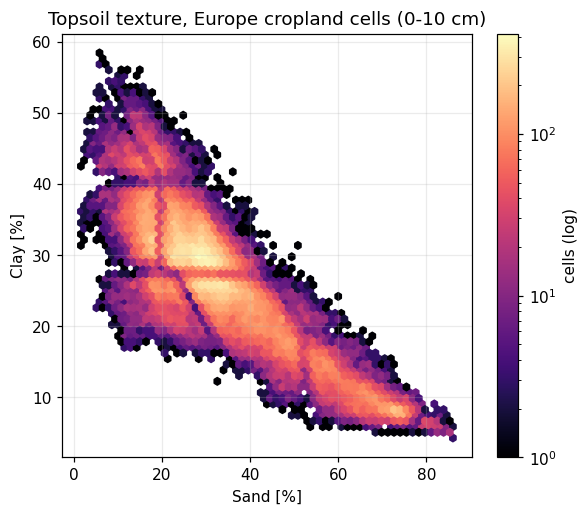

In [7]:
tex_eu = long_eu.dropna(subset=["clay", "sand"]).copy()
tex_eu["silt"] = 100 - tex_eu["clay"] - tex_eu["sand"]
bad = int((tex_eu["silt"] < -0.5).sum()) + int((tex_eu["silt"] > 100.5).sum())
print(f"clay+sand range : [{(tex_eu.clay+tex_eu.sand).min():.2f}, {(tex_eu.clay+tex_eu.sand).max():.2f}]")
print(f"implied silt    : [{tex_eu.silt.min():.2f}, {tex_eu.silt.max():.2f}]")
print(f"out-of-range cell-layers: {bad}   (must be 0)")

fig, ax = plt.subplots(figsize=(6, 5))
sub = tex_eu[tex_eu.layer == 1]
hb = ax.hexbin(sub.sand, sub.clay, gridsize=60, cmap="magma", bins="log", mincnt=1)
ax.set_xlabel("Sand [%]"); ax.set_ylabel("Clay [%]")
ax.set_title("Topsoil texture, Europe cropland cells (0-10 cm)")
fig.colorbar(hb, ax=ax, label="cells (log)")
plt.show()

### 6.5 Continental maps — topsoil (0–10 cm)

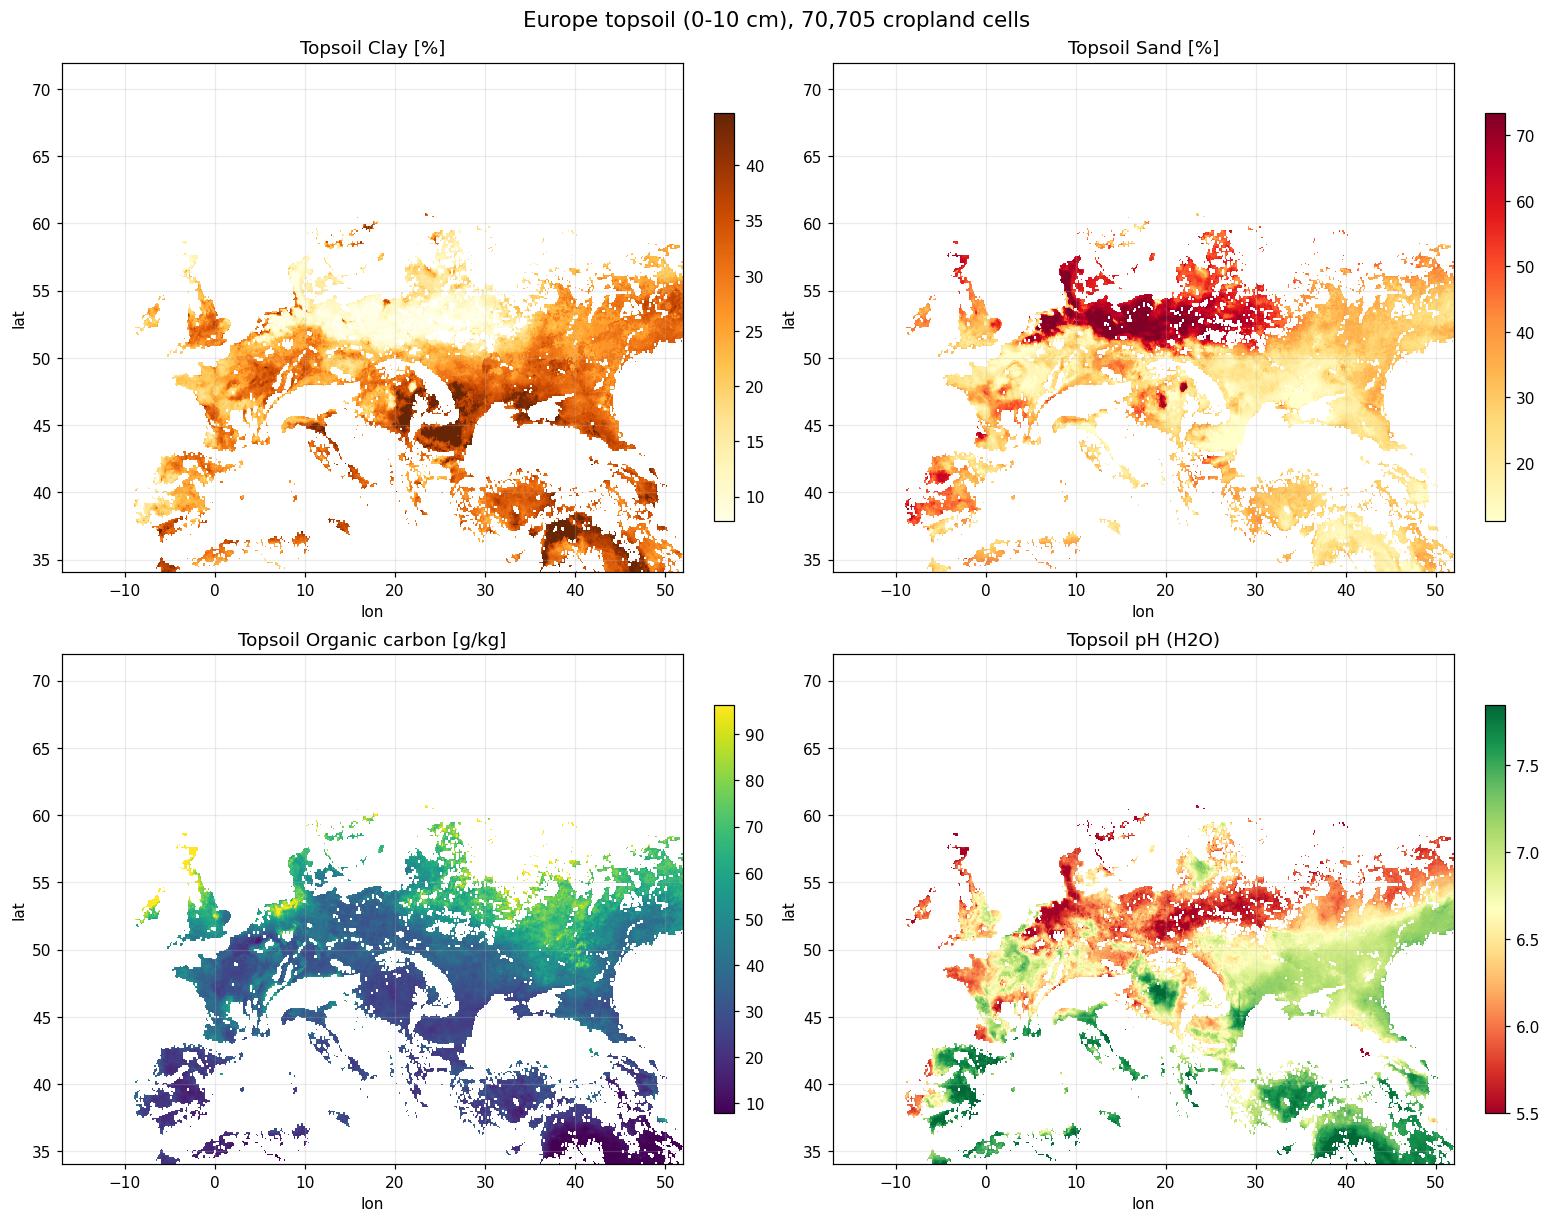

In [8]:
# Redefined here so section 6 can be run on its own (also defined in 2.2).
def grid_image(df, value, row="row", col="col"):
    img = np.full(grid.shape, np.nan)
    img[df[row].astype(int), df[col].astype(int)] = df[value].values
    return img

extent_eu = [grid.lon_centers.min(), grid.lon_centers.max(),
             grid.lat_centers.min(), grid.lat_centers.max()]
top_eu = long_eu[long_eu.layer == 1]

panels = [("clay", "Clay [%]", "YlOrBr"), ("sand", "Sand [%]", "YlOrRd"),
          ("carbon", "Organic carbon [g/kg]", "viridis"), ("PH", "pH (H2O)", "RdYlGn"),
          ("bulkdensity", "Bulk density [kg/dm3]", "cividis")]
fig, axes = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)
for ax, (var, title, cmap) in zip(axes.ravel(), panels):
    img = grid_image(top_eu, var)
    v = top_eu[var].dropna()
    im = ax.imshow(img, extent=extent_eu, origin="upper", cmap=cmap, aspect="auto",
                   vmin=v.quantile(0.02), vmax=v.quantile(0.98))
    ax.set_title(f"Topsoil {title}")
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.colorbar(im, ax=ax, shrink=0.8)
for ax in axes.ravel()[len(panels):]:  # 5 panels in a 2x3 grid
    ax.set_visible(False)
fig.suptitle(f"Europe topsoil (0-10 cm), {top_eu[panels[0][0]].notna().sum():,} cropland cells",
             fontsize=14)
plt.show()

### 6.6 Depth profiles by latitude band

Median profile with IQR, split into latitude bands so the Mediterranean,
temperate and boreal cropland are not averaged into one curve.

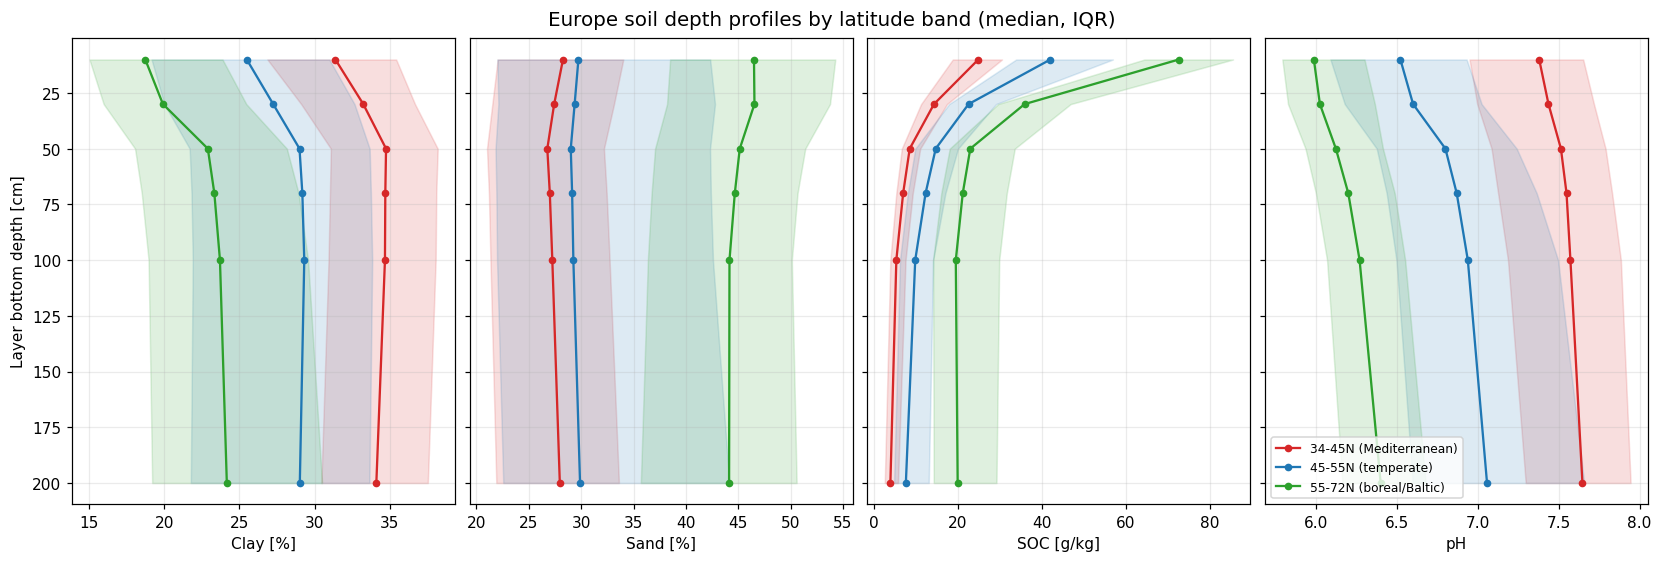

In [9]:
bands = [(34, 45, "34-45N (Mediterranean)"), (45, 55, "45-55N (temperate)"),
         (55, 72, "55-72N (boreal/Baltic)")]
prof_vars = [("clay", "Clay [%]"), ("sand", "Sand [%]"),
             ("carbon", "SOC [g/kg]"), ("PH", "pH")]

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=True, constrained_layout=True)
depths = np.array(SIMPLACE_BOTTOMS_CM)
colors = ["tab:red", "tab:blue", "tab:green"]
for ax, (var, title) in zip(axes, prof_vars):
    for (lo, hi, label), c in zip(bands, colors):
        sub = long_eu[(long_eu.lat >= lo) & (long_eu.lat < hi)]
        g = sub.groupby("layer")[var]
        ax.plot(g.median().values, depths, "-o", color=c, label=label, ms=4)
        ax.fill_betweenx(depths, g.quantile(.25).values, g.quantile(.75).values,
                         alpha=0.15, color=c)
    ax.set_xlabel(title)
axes[0].set_ylabel("Layer bottom depth [cm]")
axes[0].invert_yaxis()
axes[-1].legend(fontsize=8, loc="best")
fig.suptitle("Europe soil depth profiles by latitude band (median, IQR)", fontsize=13)
plt.show()

### 6.7 Verdict

| Check | Where |
| --- | --- |
| One row per cell, no duplicates, IDs in range | §6 |
| Shard rows == mosaicked `soil.csv` rows | §6.2 |
| Exported cells ⊆ PROBA-V cropland cells | §6.2 |
| Cropland cells dropped for lack of own-pixel soil | §6.2 |
| How many columns are real vs reference constants | §6.1 |
| No sentinels left in SoilGrids-derived columns | §6.3 |
| Texture closes to 100 % | §6.4 |

If §6.1 reports ~111 constant columns, `compute_ptf` is off and the whole
water-retention block plus `soiltype` carry one Brandenburg profile (`AP5`) for
every cell in Europe. That is expected for the current `config.yaml`, but it
means the SIMPLACE water balance is decoupled from the texture this pipeline
aggregated per cell.

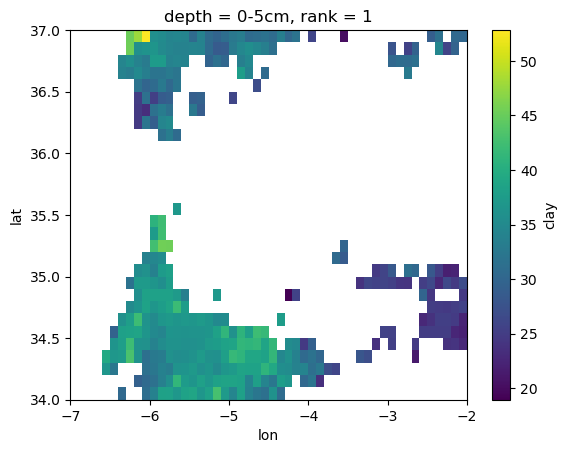

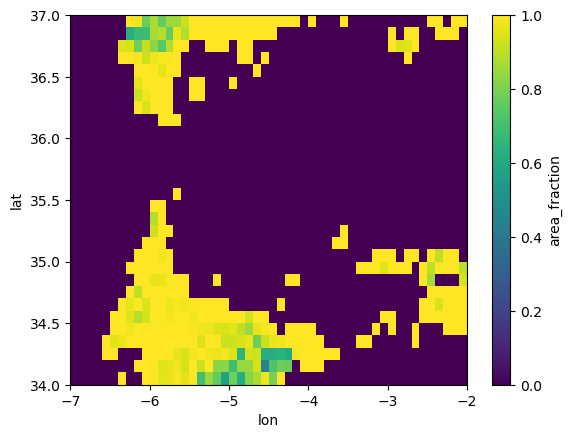

In [25]:
import xarray as xr
import matplotlib.pyplot as plt
TILE = 'tile_350_100'
ds = xr.open_dataset(OUT / 'soil' / 'netcdf_tiles' / f'intermediate_top3_classes_{TILE}.nc')
plt.figure()
ds['clay'].isel(rank=0,depth=0).plot()
plt.figure()
ds['area_fraction'].sum('rank').plot()

In [1]:
import xarray as xr
ds = xr.open_dataset('/data01/FDS/muduchuru/Land/NPKGRIDS/NC_FILES/NPKGRIDSv1.08_wheat.nc')

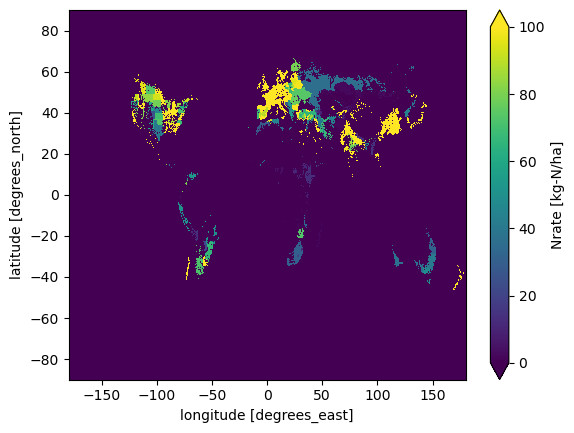

In [5]:
ds['Nrate'].plot(vmin=0,vmax=100)

In [4]:
ds

<xarray.Dataset> Size: 933MB
Dimensions:   (lon: 7200, lat: 3600)
Coordinates:
  * lon       (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * lat       (lat) float32 14kB -89.97 -89.93 -89.88 ... 89.88 89.93 89.97
Data variables:
    Nrate     (lat, lon) float32 104MB ...
    Nqual     (lat, lon) float32 104MB ...
    Nset      (lat, lon) float32 104MB ...
    P2O5rate  (lat, lon) float32 104MB ...
    P2O5qual  (lat, lon) float32 104MB ...
    P2O5set   (lat, lon) float32 104MB ...
    K2Orate   (lat, lon) float32 104MB ...
    K2Oqual   (lat, lon) float32 104MB ...
    K2Oset    (lat, lon) float32 104MB ...
Attributes:
    Creation date:  04-May-2024 18:09:47
    Authors:        F. Maggi, F.H.M. Tang, T.H. Nguyen
    Version:        v1.08